## Laboratorium 11

slajd 112 wyswietlic - ile razy algorytm sie pomylił i wybrał złego dostawcę

zadania ze slajdu 104

w 3 punkcie zmiana u dostawców (np jeden przestaje być najlepszym)

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import random

random.seed(42)

1. Reproduce example from the lecture (electronic system production)

In [133]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1

    def __init__(self, quality):
        self.quality = quality

    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)

    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good


class Factory:
    batches = []
    systems = 0
    good = 0

    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0

    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        choice = np.argmax(samples)
        result = self.batches[choice].get_element()
        self.systems = self.systems + 1
        self.good = self.good + int(result)

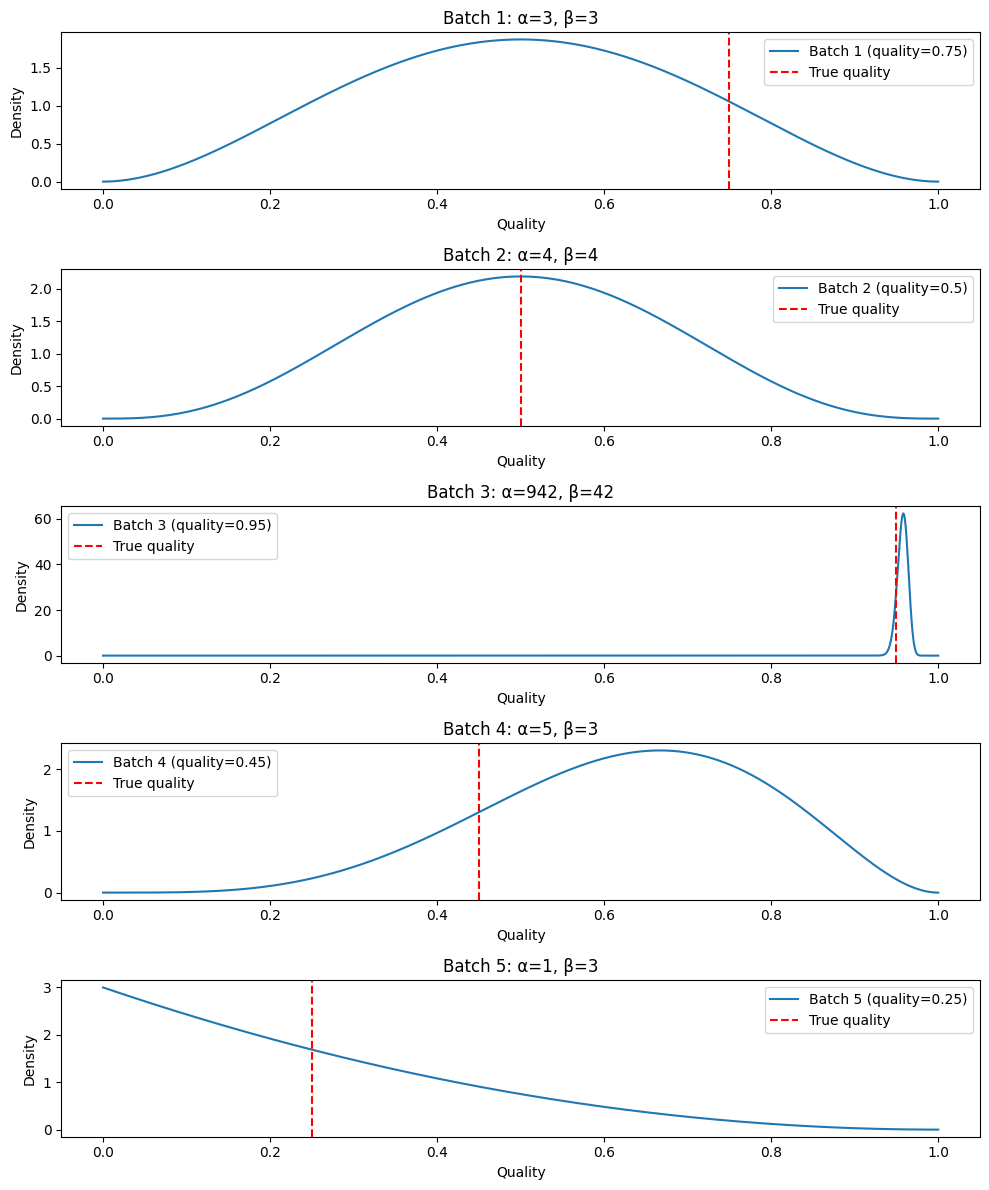

In [134]:
BATCHES_NUM = 5
qualities = [0.75, 0.5, 0.95, 0.45, 0.25]

STEPS = 1000

factory = Factory()
factory.set_batches(qualities)
res = {}

for step in range(STEPS):
    factory.get_element()
    res[step] = [(b.alpha, b.beta, b.quality) for b in factory.batches]

x = np.linspace(0,1,1000)
fig, axes = plt.subplots(BATCHES_NUM, 1, figsize=(10, 12))

for i in range(BATCHES_NUM):
    alpha_final, beta_final, quality = res[STEPS-1][i]
    y = beta.pdf(x, alpha_final, beta_final)
    axes[i].plot(x, y, label=f'Batch {i+1} (quality={quality})')
    axes[i].axvline(quality, color='r', linestyle='--', label='True quality')
    axes[i].set_title(f'Batch {i+1}: α={alpha_final}, β={beta_final}')
    axes[i].legend()
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot.

In [151]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1
    def __init__(self, quality):
        self.quality = quality
    
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good
    
class Factory:
    batches = []
    systems = 0
    good = 0

    def reset(self):
        self.systems = 0          
        self.good = 0
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.n_batches = len(qualities)
        self.systems = 0
        self.good = 0

    def step(self):
        choice = self.choose_next_method()

        result = self.batches[choice].get_element() # zwraca True dobry / False wadliwy
        self.systems = self.systems + 1
        self.good = self.good + int(result)
        return result
    
    def lemon_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        last_batch_idx = 0
        for step in range(steps):
            choice = last_batch_idx
            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            
            self.systems = self.systems + 1
            self.good = self.good + int(result)
            # print(f"Batch: {last_batch_idx}, result: {result}")
            if result == False:
                last_batch_idx = last_batch_idx + 1 if last_batch_idx + 1 < self.n_batches else 0
            results.append(result)
            
        return results.count(True), batch_success, batch_total
    
    def rank_descending_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            s = np.divide(batch_success, batch_total, out=np.zeros_like(batch_success), where=batch_total > 0)

            order = np.argsort(-s)
            choose_list = []
            for i, idx in enumerate(order):
                choose_list += [idx] * (self.n_batches - i)

            # print(schedule)
            choice = choose_list[step % len(choose_list)]

            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1

            self.systems = self.systems + 1
            self.good = self.good + int(result)
            # print(f"Batch: {choice}, result: {result}")
            results.append(result)
        
        # return sum(batch_success) / sum(batch_used)
        return results.count(True), batch_success, batch_total
    
    def ratio_geometric_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            successes = np.array([b.alpha - 1 for b in self.batches])
            failures = np.array([b.beta  - 1 for b in self.batches])
            total = successes + failures

            mean_success = np.where(total > 0, successes / total, 0.5)
            order = np.argsort(mean_success)

            sorted_success = mean_success[order]
            ratios = np.zeros(len(order))
            ratios[0] = 1.0                       
            for i in range(1, len(order)):
                if sorted_success[i-1] == 0:
                    ratios[i] = 2.0
                else:
                    ratios[i] = sorted_success[i] / sorted_success[i-1]

            schedule = []
            base_amount = 1
            for i, batch_idx in enumerate(order):
                amount = max(1, round(base_amount))
                schedule += [batch_idx] * amount
                base_amount *= ratios[i]

            position = self.systems % len(schedule)
            choice = schedule[position]

            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1

            self.systems = self.systems + 1
            self.good = self.good + int(result)
            results.append(result)
        
        return results.count(True), batch_success, batch_total

In [147]:
# BATCHES_NUM = 5
qualities = [0.3, 0.1, 0.95, 0.45, 0.75]
# qualities = [0.1, 0.3, 0.7, 0.9]

STEPS = 500
SIM_NUMS = 100

Lemon method:

In [ ]:
lemon_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.lemon_method(STEPS)
    factory.reset()
    lemon_scores.append(results / STEPS)
    
    # print(f"Success rate: {results / STEPS}")
    # print(batch_success)
    # print(batch_total)

print(f"Avg. success rate: {sum(lemon_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i}: {batch_success[i]}/{batch_total[i]}")


Avg. success rate: 0.8244199999999999
Successful batch use:
Batch 0: 7.0/25.0
Batch 1: 3.0/21.0
Batch 2: 346.0/363.0
Batch 3: 6.0/23.0
Batch 4: 51.0/68.0


Ranking descending method:

In [ ]:
rank_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.rank_descending_method(STEPS)
    factory.reset() 
    rank_scores.append(results / STEPS)

print(f"Avg. success rate: {sum(rank_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i}: {batch_success[i]}/{batch_total[i]}")


Avg. success rate: 0.6401
Successful batch use:
Batch 0: 19.0/69.0
Batch 1: 2.0/39.0
Batch 2: 159.0/164.0
Batch 3: 50.0/103.0
Batch 4: 95.0/125.0


In [ ]:
ratio_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.ratio_geometric_method(STEPS)
    factory.reset() 
    ratio_scores.append(results / STEPS)

print(f"Avg. success rate: {sum(ratio_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i}: {batch_success[i]}/{batch_total[i]}")


C:\Users\jasin\AppData\Local\Temp\ipykernel_18992\2900310164.py:99: RuntimeWarning: invalid value encountered in divide
  mean_success = np.where(total > 0, successes / total, 0.5)


Avg. success rate: 0.7217399999999999
Successful batch use:
Batch 0: 8.0/27.0
Batch 1: 8.0/59.0
Batch 2: 289.0/310.0
Batch 3: 19.0/36.0
Batch 4: 46.0/68.0
